# 01 — Exploratory Data Analysis

Load and explore retail transaction data.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

from src.data.loader import load_data

DATA_PATH = "../data/raw/transaction_data.csv"

df = load_data(DATA_PATH)

df.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0,69,PRODUCE,Private,POTATOES,POTATOES RUSSET (BULK&BAG),5 LB
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0,2,PRODUCE,National,ONIONS,ONIONS SWEET (BULK&BAG),40 LB
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0,69,PRODUCE,Private,VEGETABLES - ALL OTHERS,CELERY,
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0,2,PRODUCE,National,TROPICAL FRUIT,BANANAS,40 LB
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0,69,PRODUCE,Private,ORGANICS FRUIT & VEGETABLES,ORGANIC CARROTS,1 LB


In [3]:
df.shape

(2595732, 18)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2595732 entries, 0 to 2595731
Data columns (total 18 columns):
 #   Column                Dtype  
---  ------                -----  
 0   household_key         int64  
 1   BASKET_ID             int64  
 2   DAY                   int64  
 3   PRODUCT_ID            int64  
 4   QUANTITY              int64  
 5   SALES_VALUE           float64
 6   STORE_ID              int64  
 7   RETAIL_DISC           float64
 8   TRANS_TIME            int64  
 9   WEEK_NO               int64  
 10  COUPON_DISC           float64
 11  COUPON_MATCH_DISC     float64
 12  MANUFACTURER          int64  
 13  DEPARTMENT            str    
 14  BRAND                 str    
 15  COMMODITY_DESC        str    
 16  SUB_COMMODITY_DESC    str    
 17  CURR_SIZE_OF_PRODUCT  str    
dtypes: float64(4), int64(9), str(5)
memory usage: 356.5 MB


In [4]:
df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
DAY,2530342.0,388.578932,189.855115,1.00,229.00,390.00,553.00,711.00
STORE_ID,2530342.0,350.147846,88.600205,0.00,276.00,388.00,421.00,580.00
PRODUCT_ID,2530342.0,48522.520898,31198.761063,0.00,14275.00,60714.50,75053.00,91904.00
QUANTITY,2530342.0,103.022073,1549.472281,1.00,1.00,1.00,1.00,122583.00
SALES_VALUE,2530342.0,3.184330,4.901786,0.01,1.29,2.09,3.49,840.00
RETAIL_DISC,2530342.0,-0.546809,1.297475,-180.00,-0.69,-0.04,0.00,3.99
COUPON_DISC,2530342.0,-0.012739,0.172992,-55.93,0.00,0.00,0.00,0.00
COUPON_MATCH_DISC,2530342.0,-0.002992,0.040548,-10.85,0.00,0.00,0.00,0.00
BASKET_ID,2530342.0,1.018366,0.152377,1.00,1.00,1.00,1.00,8.00
WEEK_NO,2530342.0,56.196427,27.121410,1.00,33.00,56.00,80.00,102.00


In [5]:
missing = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0]

Series([], dtype: int64)

In [6]:
stats = {
    "transactions": df["BASKET_ID"].nunique(),
    "products": df["PRODUCT_ID"].nunique(),
    "stores": df["STORE_ID"].nunique(),
    "brand": df["BRAND"].nunique()
}

pd.Series(stats)

transactions    276484
products         92339
stores             582
brand                2
dtype: int64

In [7]:
print("Number of transactions days:", len(df.groupby(["DAY"])))
print("Last day number:", max(df["DAY"]))

print(df["QUANTITY"].describe())

print(
    "Zero quantity:",
    (df["QUANTITY"] == 0).mean()
)

Number of transactions days: 711
Last day number: 711
count    2.595732e+06
mean     1.004286e+02
std      1.153436e+03
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      8.963800e+04
Name: QUANTITY, dtype: float64
Zero quantity: 0.005572994438562995


In [23]:
n_products = df["PRODUCT_ID"].nunique()
n_stores = df["STORE_ID"].nunique()

print("Products:", n_products)
print("Stores:", n_stores)

series = df.groupby(["COMMODITY_DESC", "WEEK_NO"]).size()

series.describe()

Products: 92339
Stores: 582


count    27598.000000
mean        94.055076
std        152.331205
min          1.000000
25%         10.000000
50%         39.000000
75%        115.000000
max       1687.000000
dtype: float64

In [15]:
product_stats = (
    df.groupby("PRODUCT_ID")
    .agg(
        active_days=("DAY", "nunique"),
        total_quantity=("QUANTITY", "sum")
    )
)

product_stats.describe()

,active_days,total_quantity
count,92339.000000,9.233900e+04
mean,20.012931,2.823137e+03
std,52.369538,7.167374e+05
min,1.000000,0.000000e+00
25%,1.000000,1.000000e+00
50%,3.000000,3.000000e+00
75%,13.000000,1.500000e+01
max,708.000000,2.165322e+08


In [20]:
def product_segment(row):
    if row["active_days"] >= 100:
        return "frequent"

    elif row["active_days"] >= 20:
        return "medium"

    else:
        return "rare"


product_stats["segment"] = (
    product_stats.apply(product_segment, axis=1)
)
print(len(product_stats[product_stats["segment"] == "rare"]))

74053


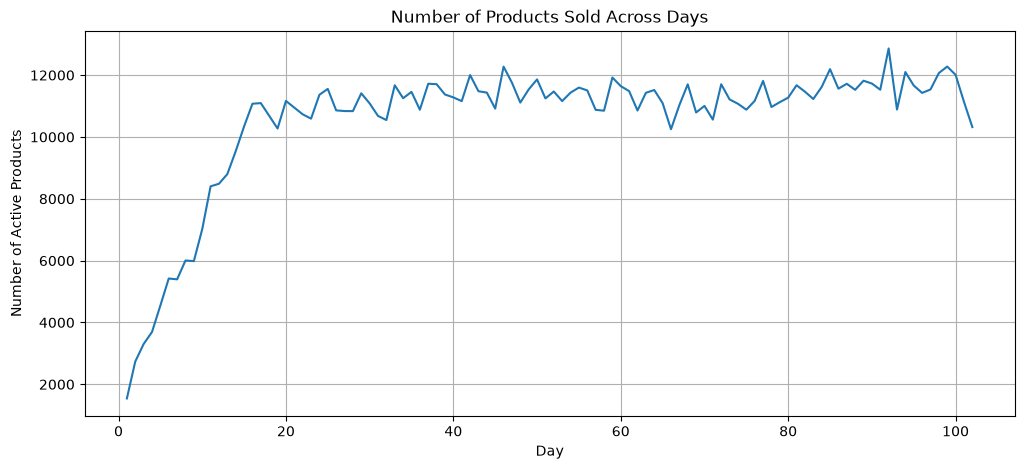

In [12]:
import matplotlib.pyplot as plt

daily_products = (
    df.groupby("WEEK_NO")["PRODUCT_ID"]
    .nunique()
)

plt.figure(figsize=(12, 5))

plt.plot(
    daily_products.index,
    daily_products.values
)

plt.xlabel("Day")
plt.ylabel("Number of Active Products")
plt.title("Number of Products Sold Across Days")

plt.grid(True)
plt.show()

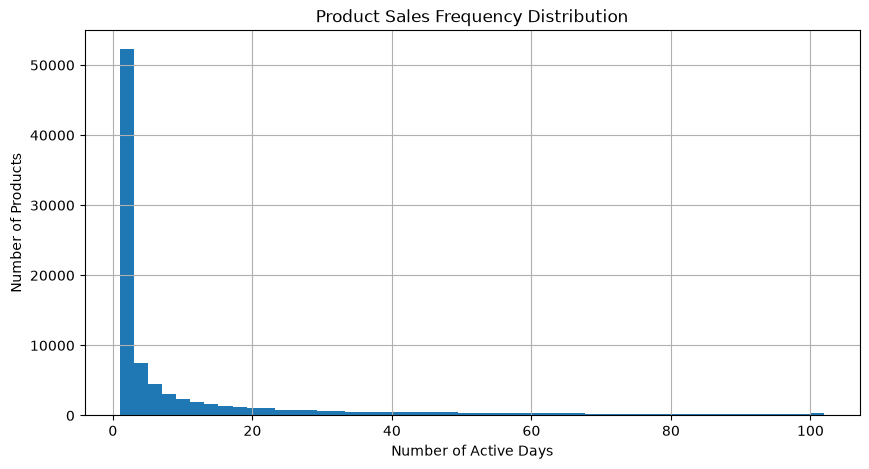

In [11]:
product_days = (
    df.groupby("PRODUCT_ID")["WEEK_NO"]
    .nunique()
)

plt.figure(figsize=(10, 5))

plt.hist(
    product_days,
    bins=50
)

plt.xlabel("Number of Active Days")
plt.ylabel("Number of Products")
plt.title("Product Sales Frequency Distribution")

plt.grid(True)
plt.show()

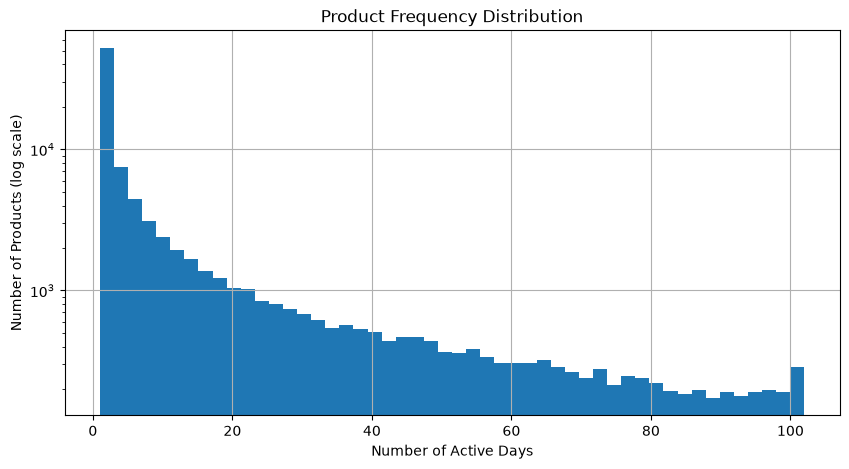

In [13]:
plt.figure(figsize=(10, 5))

plt.hist(
    product_days,
    bins=50,
    log=True
)

plt.xlabel("Number of Active Days")
plt.ylabel("Number of Products (log scale)")
plt.title("Product Frequency Distribution")

plt.grid(True)
plt.show()

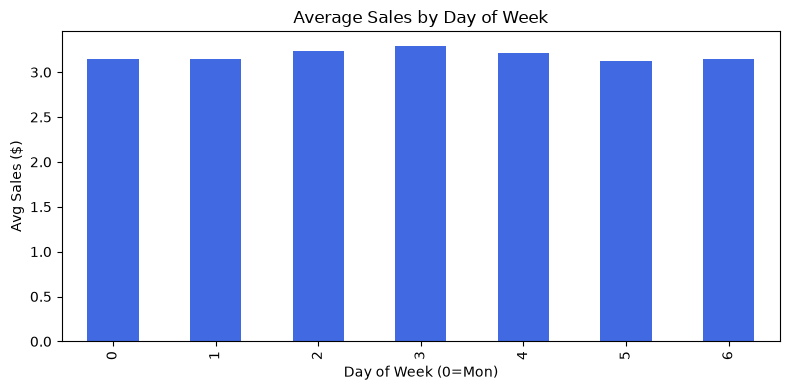

In [8]:
# Week-over-week sales (rough day-of-week view)
df["day_of_week"] = df["DAY"] % 7
dow_sales = df.groupby("day_of_week")["SALES_VALUE"].mean()

plt.figure(figsize=(8, 4))
dow_sales.plot(kind="bar", color="royalblue")
plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week (0=Mon)")
plt.ylabel("Avg Sales ($)")
plt.tight_layout()
plt.show()